In [20]:
import sys
from pathlib import Path

current_dir = Path.cwd()

root_dir = current_dir
while not (root_dir / 'utils').is_dir() and root_dir != root_dir.parent:
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,ConfusionMatrixDisplay
from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from sklearn.utils import resample
from utils.model_manager import save_model_package

In [22]:
from scipy.sparse import issparse
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           
        
    def is_leaf_node(self):
        return self.value is not None

In [23]:
from scipy.sparse import issparse
class DecisionTreeScratch:
    def __init__(self, min_samples_split=2, max_depth=10, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None
    
    def get_params(self, deep=True):
        return {
            "min_samples_split": self.min_samples_split,
            "max_depth": self.max_depth,
            "n_features": self.n_features
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def fit(self, X, y):
        y = np.array(y).flatten()
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)
        return self
    
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if n_samples == 0:
            return Node(value=0)

        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feature is None:
            return Node(value=self._most_common_label(y))

        X_column = X[:, best_feature]
        if issparse(X_column):
            X_column = X_column.toarray().flatten()

        left_idxs, right_idxs = self._split(X_column, best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            
            if issparse(X_column):
                X_column = X_column.toarray().flatten()
            
            percentiles = np.percentile(X_column, [20, 40, 60, 80])
            thresholds = np.unique(percentiles) 

            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr
                    
        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)

        left_idxs, right_idxs = self._split(X_column, threshold)
        

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return -1 
        
        n = len(y)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (len(left_idxs) / n) * e_l + (len(right_idxs) / n) * e_r

        gain = parent_entropy - child_entropy
        return gain

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        preds = []
        for i in range(X.shape[0]):
            x_row = X[i].toarray().flatten() if issparse(X) else X[i]
            preds.append(self._traverse_tree(x_row, self.root))
        return np.array(preds)

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [24]:
class RandomForestClassifierScratch:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        if hasattr(y, "values"):
            y = y.values
        else:
            y = np.array(y).flatten()
            
        self.trees = []
        for _ in range(self.n_estimators):
            X_samp, y_samp = self._bootstrap_samples(X, y)
            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=int(np.sqrt(X.shape[1]))
            )
            tree.fit(X_samp, y_samp)
            self.trees.append(tree)
            
        return self

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    # def predict(self, X):
    #     # Collect predictions from all tree
    #     tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
    #     tree_preds = np.swapaxes(tree_preds, 0, 1)
        
    #     # Majority Voting
    #     return np.array([Counter(pred).most_common(1)[0][0] for pred in tree_preds])
    def predict_proba(self, X):
        if hasattr(X, "toarray"): 
            X = X.toarray()
        elif hasattr(X, "values"):
            X = X.values
        else:
            X = np.array(X)
            
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        spam_votes = np.sum(tree_preds == 1, axis=1)
        spam_probabilities = spam_votes / self.n_estimators
        
        return spam_probabilities

    def predict(self, X, threshold=0.5):
        spam_probs = self.predict_proba(X)
        return (spam_probs >= threshold).astype(int)

    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "max_depth": self.max_depth,
            "min_samples_split": self.min_samples_split
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

In [25]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

In [26]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (21906, 5001)
X_test : (5477, 5001)
y_train: (21906,)
y_test : (5477,)


In [27]:
# Defining hyperparameter grid
rf_param_grid = {
    'n_estimators': [5, 10, 15],       # number of estimator
    'max_depth': [10, 20],             # Maximum depth of each tree
    'min_samples_split': [2, 5]        # Minimum sample size for splitting
}

In [28]:
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

rf_model = RandomForestClassifierScratch()

grid_search = CustomGridSearchCV(
    estimator=rf_model, 
    param_grid=rf_param_grid, 
    cv=cv, 
    scoring='f1'
)
grid_search.fit(X_train, y_train)

Bắt đầu GridSearchCV: 12 tổ hợp tham số, 3 folds.
[1/12] Params: {'n_estimators': 5, 'max_depth': 10, 'min_samples_split': 2} --> f1: 0.8117
[2/12] Params: {'n_estimators': 5, 'max_depth': 10, 'min_samples_split': 5} --> f1: 0.8151
[3/12] Params: {'n_estimators': 5, 'max_depth': 20, 'min_samples_split': 2} --> f1: 0.8825
[4/12] Params: {'n_estimators': 5, 'max_depth': 20, 'min_samples_split': 5} --> f1: 0.8592
[5/12] Params: {'n_estimators': 10, 'max_depth': 10, 'min_samples_split': 2} --> f1: 0.7711
[6/12] Params: {'n_estimators': 10, 'max_depth': 10, 'min_samples_split': 5} --> f1: 0.7988
[7/12] Params: {'n_estimators': 10, 'max_depth': 20, 'min_samples_split': 2} --> f1: 0.8556
[8/12] Params: {'n_estimators': 10, 'max_depth': 20, 'min_samples_split': 5} --> f1: 0.8698
[9/12] Params: {'n_estimators': 15, 'max_depth': 10, 'min_samples_split': 2} --> f1: 0.8528
[10/12] Params: {'n_estimators': 15, 'max_depth': 10, 'min_samples_split': 5} --> f1: 0.8262
[11/12] Params: {'n_estimators': 

In [29]:
# Get the best model
best_rf_model = grid_search.best_estimator_
best_rf_params = grid_search.best_params_

In [30]:
probs = best_rf_model.predict_proba(X_test)

if len(probs.shape) > 1 and probs.shape[1] == 2:
    probs = probs[:, 1]
else:
    probs = probs.flatten()

candidate_thresholds = np.linspace(0.5, 1.0, 51)

target_threshold = 0.5
closest_fpr = 1.0

print(f"{'Threshold':<12}{'FP':<8}{'TN':<8}{'FPR (%)':<12}{'TPR (Recall) (%)':<15}")
print("-" * 55)

printed_fprs = set()

for th in candidate_thresholds:
    preds = (probs >= th).astype(int)
    
    tp_c = np.sum((y_test == 1) & (preds == 1))
    fp_c = np.sum((y_test == 0) & (preds == 1))
    tn_c = np.sum((y_test == 0) & (preds == 0))
    fn_c = np.sum((y_test == 1) & (preds == 0))
    
    fpr_c = fp_c / (fp_c + tn_c) if (fp_c + tn_c) > 0 else 0
    tpr_c = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0
    
    if 0.00 <= fpr_c <= 0.05:
        if fpr_c not in printed_fprs:
            print(f"{th:<12.4f}{fp_c:<8}{tn_c:<8}{fpr_c*100:<12.2f}{tpr_c*100:<15.2f}")
            printed_fprs.add(fpr_c)
        
    if abs(fpr_c - 0.01) < abs(closest_fpr - 0.01):
        closest_fpr = fpr_c
        target_threshold = th

print(f"Threshold tốt nhất: {target_threshold:.4f}")
print(f"FPR đạt được tại threshold đó: {closest_fpr*100:.2f}%")

Threshold   FP      TN      FPR (%)     TPR (Recall) (%)
-------------------------------------------------------
0.6700      113     2772    3.92        84.22          
0.7400      52      2833    1.80        74.34          
0.8100      9       2876    0.31        52.66          
0.8700      2       2883    0.07        32.10          
0.9400      0       2885    0.00        13.04          
Threshold tốt nhất: 0.8100
FPR đạt được tại threshold đó: 0.31%


In [31]:
# y_pred = best_rf_model.predict(X_test)
y_pred = best_rf_model.predict(X_test, threshold=0.8700)

In [32]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [33]:
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

Accuracy : 0.6783
Precision: 0.9976
Recall   : 0.3210
F1 Score : 0.4857


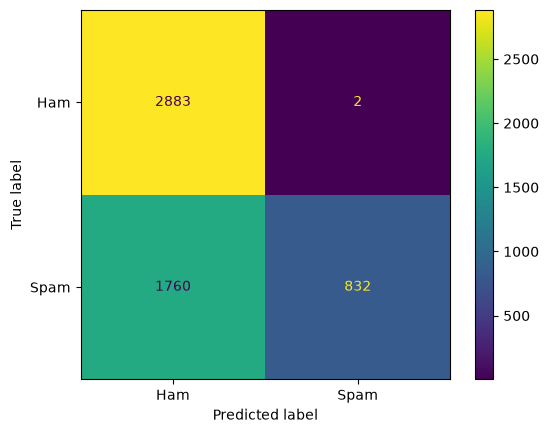

In [34]:
cm = confusion_matrix(y_test, y_pred)

# Visualize prediction results
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
).plot()

plt.show()

In [35]:
metrics_rf_classification = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1
}

save_model_package(
    model=None,
    model_name="Random_Forest_Scratch",
    best_params=best_rf_params,
    metrics=metrics_rf_classification,
    save_dir='./models'
)


'models\\Random_Forest_Scratch.pkl'